<a href="https://colab.research.google.com/github/RaniaChaudhry511/SUPERWISED-MACHINE-LEARING-MODEL/blob/main/logistic_regression_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                                         LOGISTIC REGRESSION(ALGORITHM)PROJECT

                                                  LOAN ELIGIBILITY PREDICTION USING LOGISTIC REGRESSION

                                                            DATA LOADING AND UNDERSTANDING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
df = pd.read_csv("/content/Loan Eligibility Prediction.csv")
df

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,480,Male,Yes,2,Graduate,No,2947,1603.0,10,360,1,Urban,N
610,525,Male,No,0,Graduate,No,4680,2087.0,15,360,1,Semiurban,N
611,551,Male,Yes,2,Graduate,Yes,6633,0.0,25,360,0,Rural,N
612,552,Male,Yes,1,Not Graduate,No,2492,2375.0,30,360,1,Rural,Y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.columns

Index(['Customer_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Applicant_Income', 'Coapplicant_Income',
       'Loan_Amount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status'],
      dtype='object')

In [ ]:
df.dtypes

,0
Customer_ID,int64
Gender,object
Married,object
Dependents,int64
Education,object
Self_Employed,object
Applicant_Income,int64
Coapplicant_Income,float64
Loan_Amount,int64
Loan_Amount_Term,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB


In [ ]:
df.describe()

,Customer_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,307.500000,0.856678,5403.459283,1621.245798,142.022801,338.892508,0.850163
std,177.390811,1.216651,6109.041673,2926.248369,87.083089,69.716355,0.357203
min,1.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,154.250000,0.000000,2877.500000,0.000000,98.000000,360.000000,1.000000
50%,307.500000,0.000000,3812.500000,1188.500000,125.000000,360.000000,1.000000
75%,460.750000,2.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,614.000000,4.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


                                                           STEP 2    DATA CLEANING

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
Applicant_Income,0
Coapplicant_Income,0
Loan_Amount,0
Loan_Amount_Term,0


In [ ]:
df.duplicated().sum()

np.int64(0)

                                                                   OUTLIERS

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Loan Eligibility Prediction.csv')

numerical_cols = ['Applicant_Income', 'Coapplicant_Income',
                  'Loan_Amount', 'Loan_Amount_Term']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Applicant_Income: 50 outliers
Coapplicant_Income: 18 outliers
Loan_Amount: 41 outliers
Loan_Amount_Term: 97 outliers


In [ ]:
for col in ['Applicant_Income', 'Coapplicant_Income', 'Loan_Amount']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("Done! Capping ho gayi.")

Done! Capping ho gayi.


Why Loan_Amount_Term was excluded from outlier treatment:
Loan_Amount_Term represents fixed loan tenure options offered by the bank such as 360 months, 180 months, 120 months, and 60 months. These are not random extreme values — they are standard predefined categories set by the financial institution. Since IQR method flags less frequent values as outliers, it incorrectly marks the rare term options like 36 or 480 months as outliers. In reality, these are valid business values. Applying capping or removal on this column would distort the actual loan term information and mislead the model. Therefore, Loan_Amount_Term was intentionally excluded from outlier treatment.


In [ ]:
for col in ['Applicant_Income', 'Coapplicant_Income', 'Loan_Amount']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Applicant_Income: 0 outliers
Coapplicant_Income: 0 outliers
Loan_Amount: 0 outliers


                                                           STEP 3 EDA(EXPLORATORY DATA ANALYSIS)

                                                             UNIVARIATE ANALYSIS

--- Applicant_Income ---
Mean   : 4617.11
Median : 3812.50
Std    : 2479.85
Distribution : Skewed



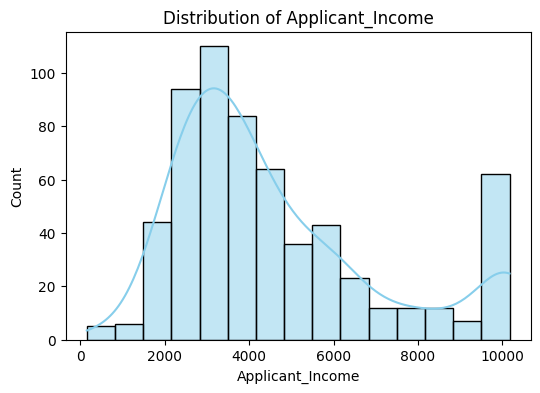

--- Coapplicant_Income ---
Mean   : 1419.70
Median : 1188.50
Std    : 1624.61
Distribution : Skewed



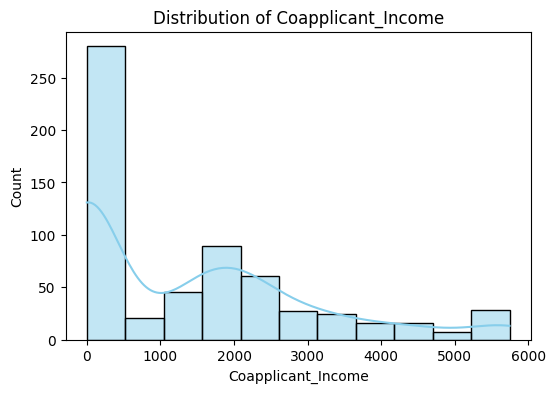

--- Loan_Amount ---
Mean   : 133.86
Median : 125.00
Std    : 60.14
Distribution : Skewed



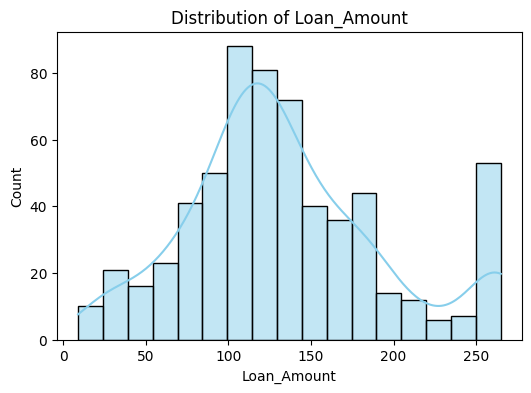

--- Loan_Amount_Term ---
Mean   : 338.89
Median : 360.00
Std    : 69.72
Distribution : Skewed



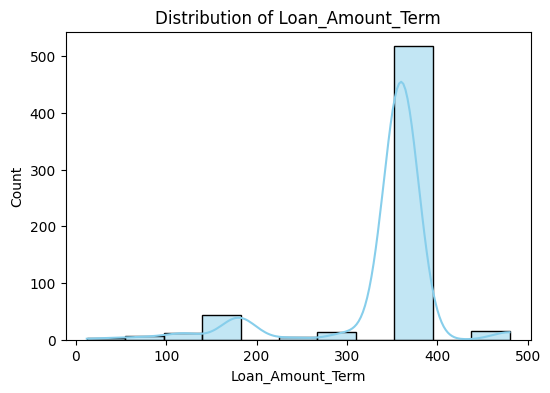

--- Gender ---
Gender
Male      499
Female    115
Name: count, dtype: int64



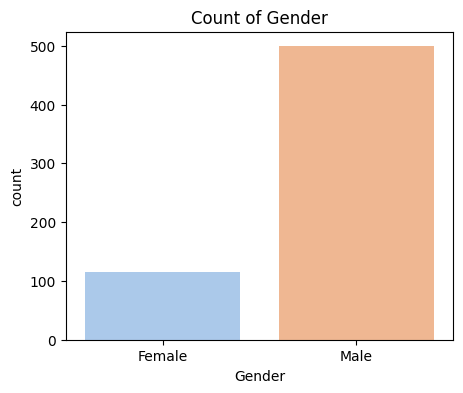

--- Married ---
Married
Yes    399
No     215
Name: count, dtype: int64



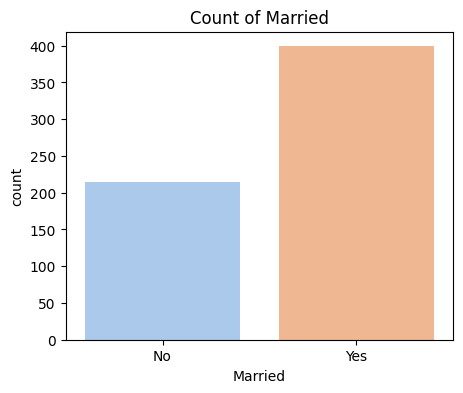

--- Education ---
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64



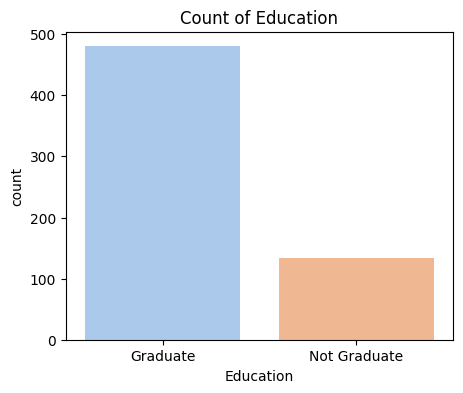

--- Self_Employed ---
Self_Employed
No     523
Yes     91
Name: count, dtype: int64



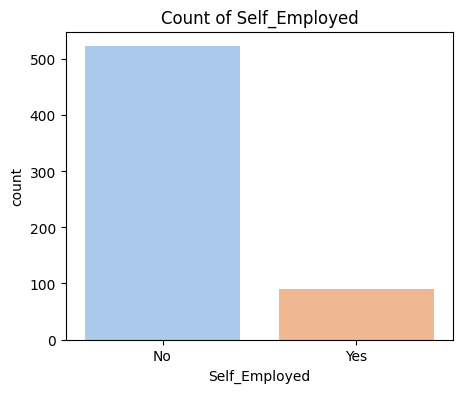

--- Credit_History ---
Credit_History
1    522
0     92
Name: count, dtype: int64



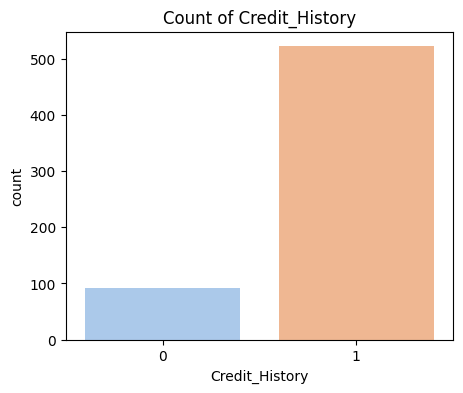

--- Loan_Status ---
Loan_Status
Y    422
N    192
Name: count, dtype: int64



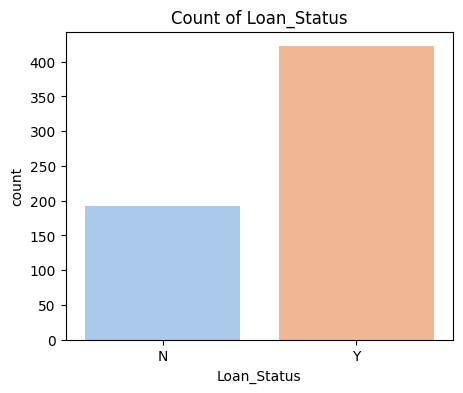

In [ ]:
numerical_cols = ['Applicant_Income', 'Coapplicant_Income',
                  'Loan_Amount', 'Loan_Amount_Term']

# Numerical - Mean, Median, Std + Histogram
for col in numerical_cols:
    mean   = df[col].mean()
    median = df[col].median()
    std    = df[col].std()

    print(f"--- {col} ---")
    print(f"Mean   : {mean:.2f}")
    print(f"Median : {median:.2f}")
    print(f"Std    : {std:.2f}")
    if abs(mean - median) < 0.05 * mean:
        print("Distribution : Symmetric")
    else:
        print("Distribution : Skewed")
    print()

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

# Categorical - value_counts + countplot
categorical_cols = ['Gender', 'Married', 'Education',
                    'Self_Employed', 'Credit_History', 'Loan_Status']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

    plt.figure(figsize=(5,4))
    sns.countplot(x=col, hue=col, data=df, palette='pastel', legend=False)
    plt.title(f'Count of {col}')
    plt.show()

                                              OBSERVATION

Numerical Graphs:

1. Applicant_Income — Mean is 4617 and Median is 3812. The data is skewed which means most applicants earn low income and only a few earn very high income.

2. Coapplicant_Income — Mean is 1419 and Median is 1188. Skewed distribution. Many applicants have zero coapplicant income meaning they are applying alone.

3. Loan_Amount — Mean is 133 and Median is 125. Skewed. Most people are requesting loans between 100 to 150.

4. Loan_Amount_Term — Mean is 338 and Median is 360. Skewed. Almost everyone has chosen 360 months which is 30 years as their loan term.

Categorical Graphs:

5. Gender — 499 Males and 115 Females. The dataset is mostly male applicants.

6. Married — 399 married and 215 unmarried. More married people are applying for loans.

7. Education — 480 Graduates and 134 Not Graduates. Most applicants are educated.

8. Self_Employed — 523 Not Self Employed and 91 Self Employed. Most applicants are salaried people.

9. Credit_History — 522 have good credit history and only 92 have bad credit history. Most applicants have a clean financial record.

10. Loan_Status — 422 Approved and 192 Rejected. The dataset is slightly imbalanced towards approved loans.


                                                                      BIVARIATE ANALYSIS

CATEGORICAL VS NUMERICAL


Gender vs Applicant_Income
Gender
Female    4422.632609
Male      4661.931363
Name: Applicant_Income, dtype: float64


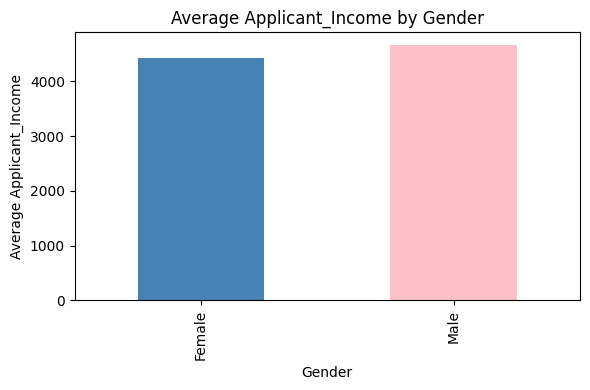


Gender vs Coapplicant_Income
Gender
Female     738.576087
Male      1576.675190
Name: Coapplicant_Income, dtype: float64


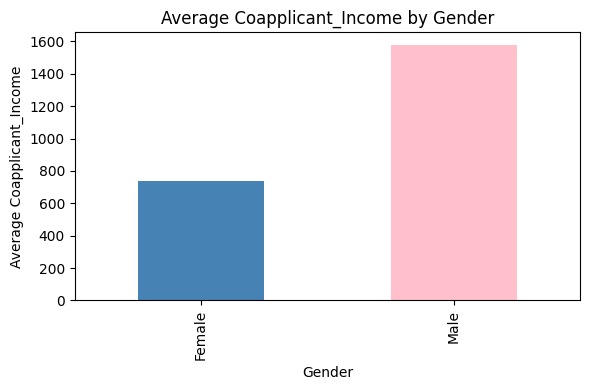


Gender vs Loan_Amount
Gender
Female    121.843478
Male      136.631012
Name: Loan_Amount, dtype: float64


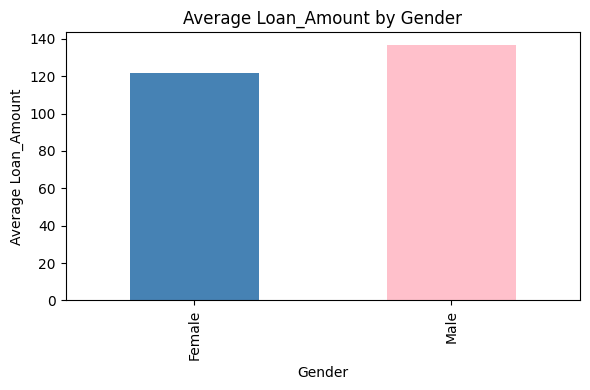


Gender vs Loan_Amount_Term
Gender
Female    345.913043
Male      337.274549
Name: Loan_Amount_Term, dtype: float64


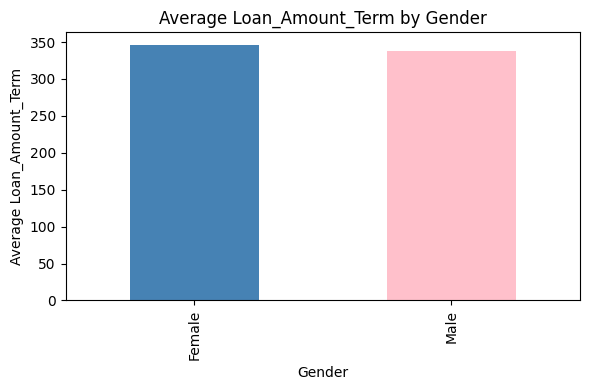


Married vs Applicant_Income
Married
No     4567.306977
Yes    4643.948622
Name: Applicant_Income, dtype: float64


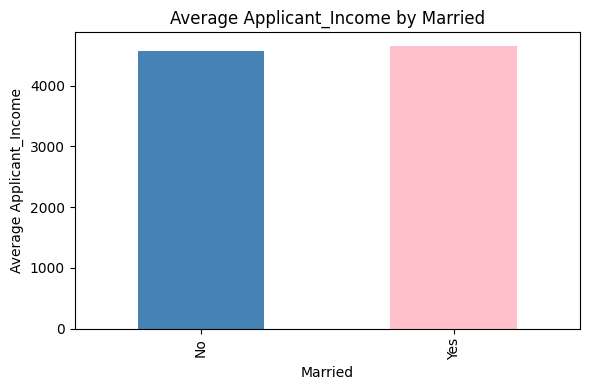


Married vs Coapplicant_Income
Married
No      918.365698
Yes    1689.845977
Name: Coapplicant_Income, dtype: float64


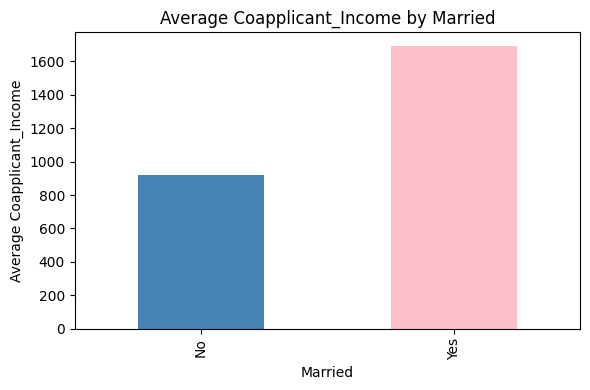


Married vs Loan_Amount
Married
No     120.282558
Yes    141.178258
Name: Loan_Amount, dtype: float64


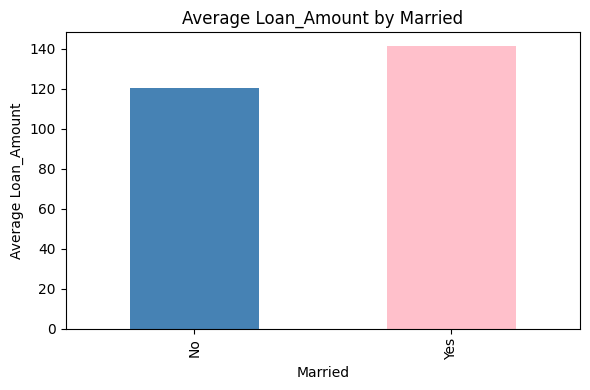


Married vs Loan_Amount_Term
Married
No     346.939535
Yes    334.556391
Name: Loan_Amount_Term, dtype: float64


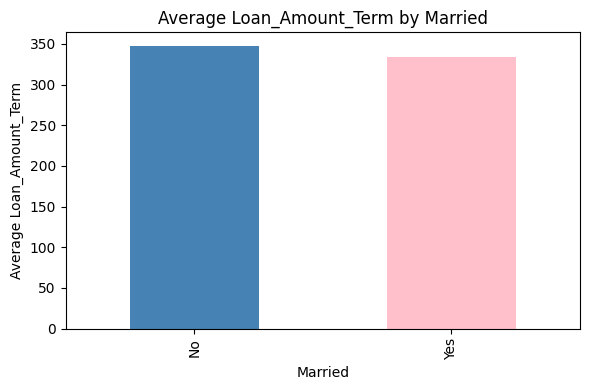


Education vs Applicant_Income
Education
Graduate        4882.991667
Not Graduate    3664.705224
Name: Applicant_Income, dtype: float64


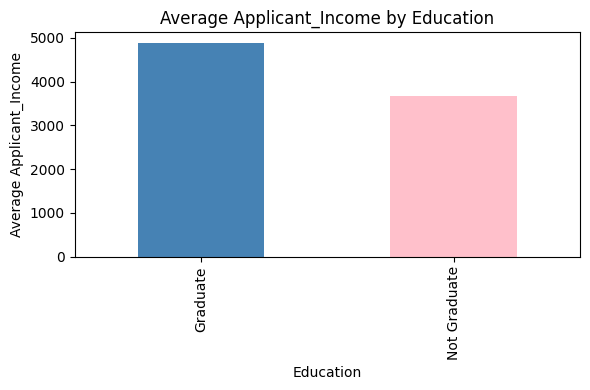


Education vs Coapplicant_Income
Education
Graduate        1462.495927
Not Graduate    1266.411381
Name: Coapplicant_Income, dtype: float64


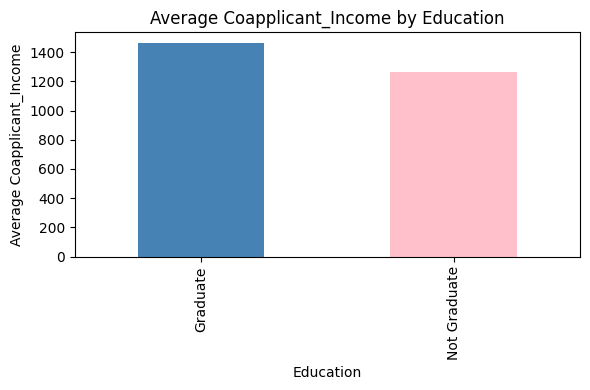


Education vs Loan_Amount
Education
Graduate        139.560417
Not Graduate    113.446828
Name: Loan_Amount, dtype: float64


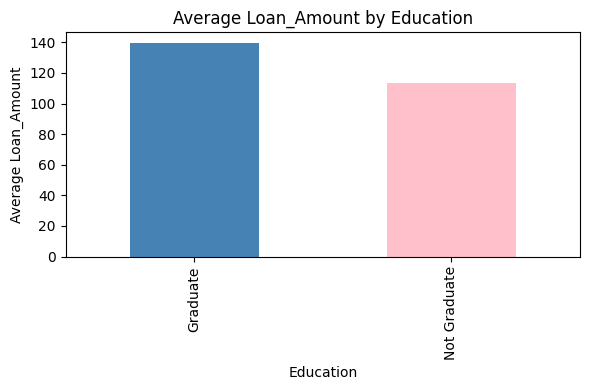


Education vs Loan_Amount_Term
Education
Graduate        342.925000
Not Graduate    324.447761
Name: Loan_Amount_Term, dtype: float64


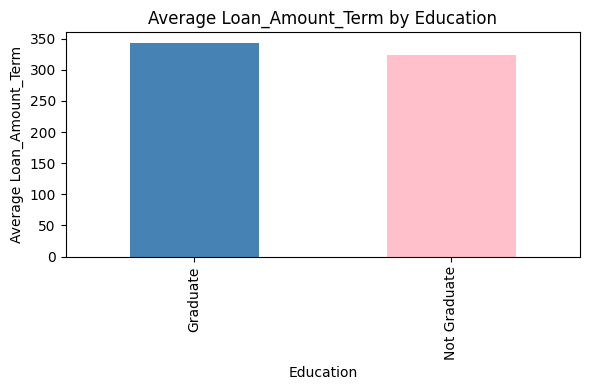


Self_Employed vs Applicant_Income
Self_Employed
No     4404.443117
Yes    5839.370879
Name: Applicant_Income, dtype: float64


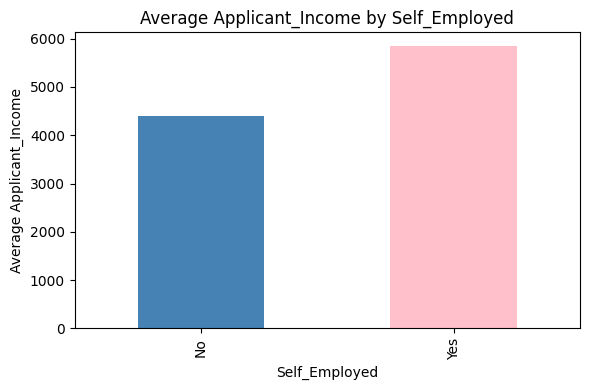


Self_Employed vs Coapplicant_Income
Self_Employed
No     1437.129627
Yes    1319.542582
Name: Coapplicant_Income, dtype: float64


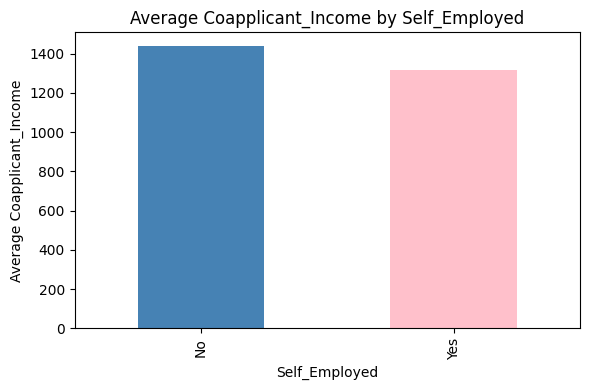


Self_Employed vs Loan_Amount
Self_Employed
No     131.409178
Yes    147.954670
Name: Loan_Amount, dtype: float64


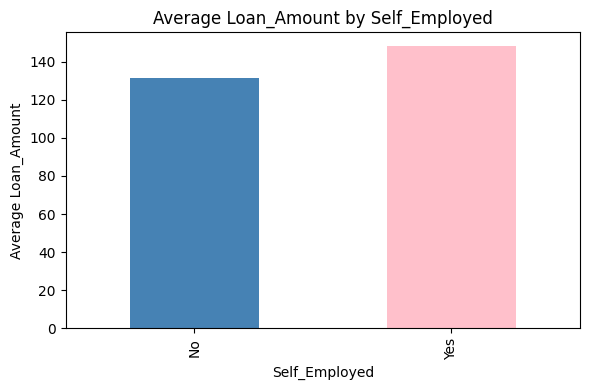


Self_Employed vs Loan_Amount_Term
Self_Employed
No     339.304015
Yes    336.527473
Name: Loan_Amount_Term, dtype: float64


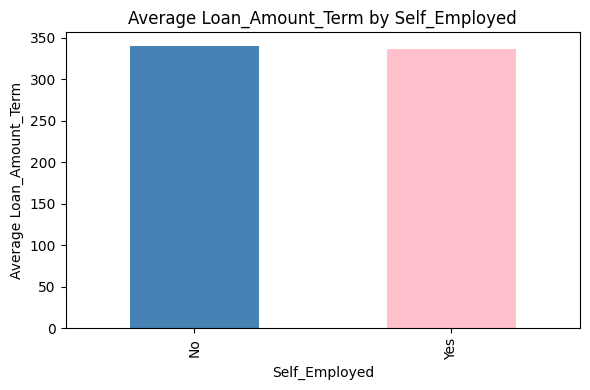


Property_Area vs Applicant_Income
Property_Area
Rural        4747.713687
Semiurban    4563.697425
Urban        4562.991337
Name: Applicant_Income, dtype: float64


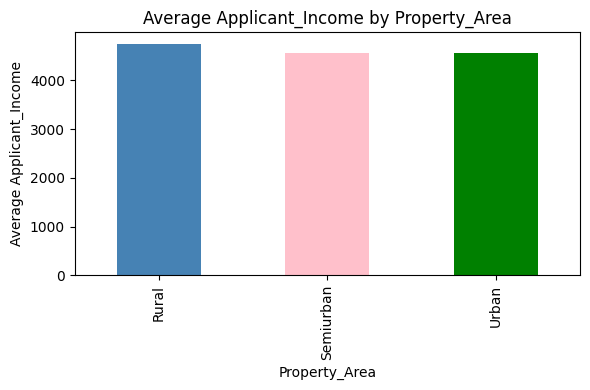


Property_Area vs Coapplicant_Income
Property_Area
Rural        1608.388939
Semiurban    1380.377146
Urban        1297.859777
Name: Coapplicant_Income, dtype: float64


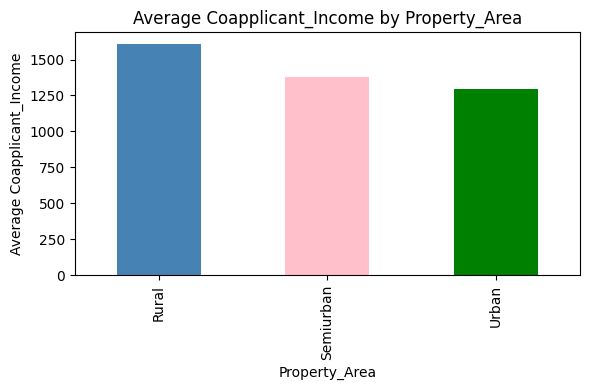


Property_Area vs Loan_Amount
Property_Area
Rural        139.481844
Semiurban    135.847103
Urban        126.590347
Name: Loan_Amount, dtype: float64


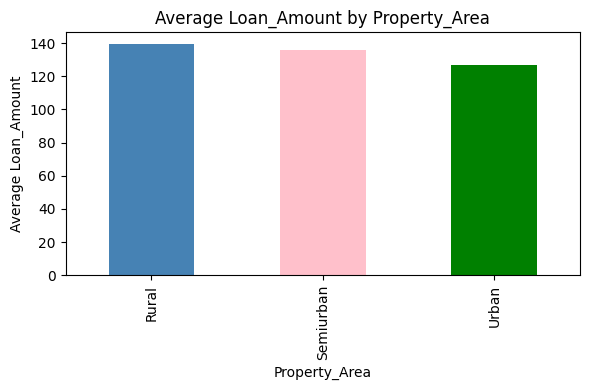


Property_Area vs Loan_Amount_Term
Property_Area
Rural        344.513966
Semiurban    346.248927
Urban        325.425743
Name: Loan_Amount_Term, dtype: float64


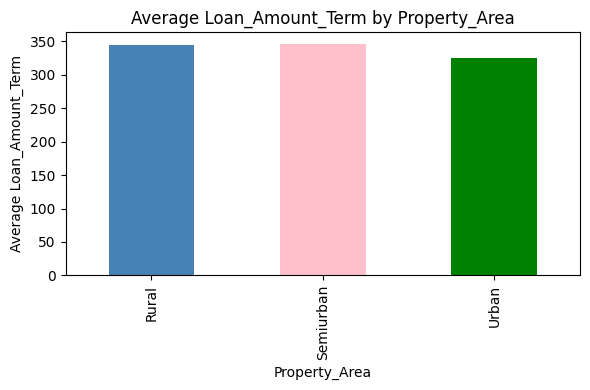

In [ ]:
categorical_cols = ['Gender', 'Married', 'Education',
                    'Self_Employed', 'Property_Area']
numerical_cols = ['Applicant_Income', 'Coapplicant_Income',
                  'Loan_Amount', 'Loan_Amount_Term']

for cat in categorical_cols:
    for num in numerical_cols:
        print(f"\n{cat} vs {num}")
        print(df.groupby(cat)[num].mean())

        plt.figure(figsize=(6,4))
        df.groupby(cat)[num].mean().plot(kind='bar', color=['steelblue','pink','green'])
        plt.title(f'Average {num} by {cat}')
        plt.xlabel(cat)
        plt.ylabel(f'Average {num}')
        plt.tight_layout()
        plt.show()

NUMERICAL VS CATEGORICAL (SCATTER PLOT)

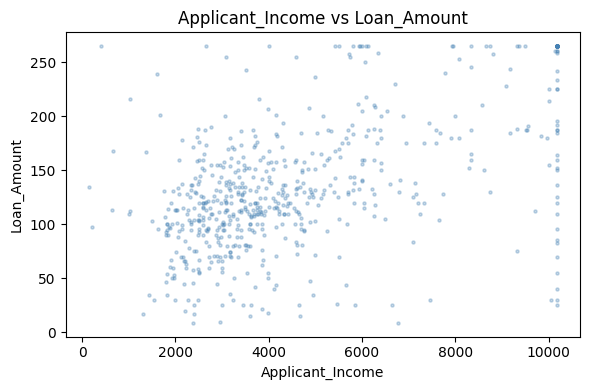

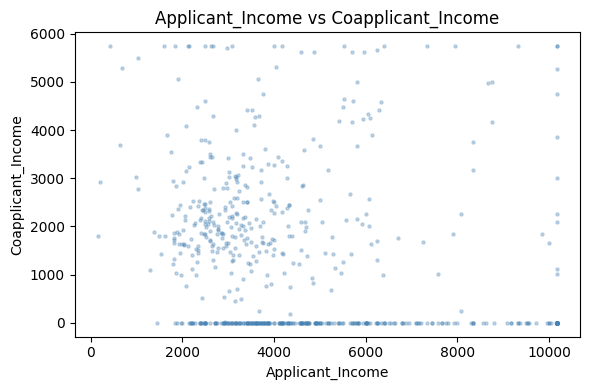

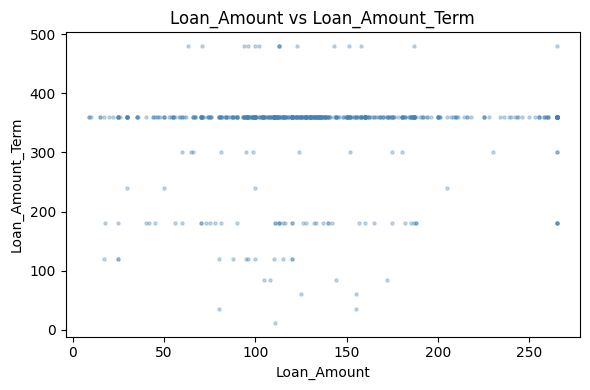

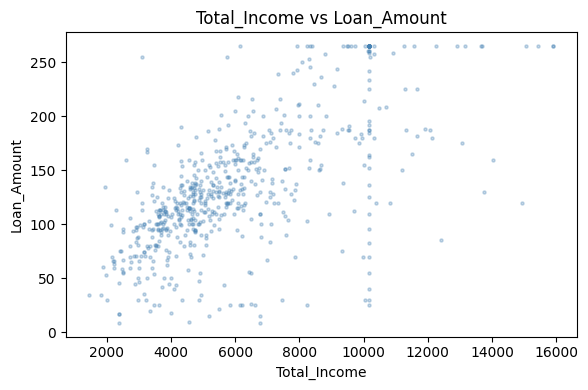

In [ ]:
df['Total_Income'] = df['Applicant_Income'] + df['Coapplicant_Income']

pairs = [
    ('Applicant_Income', 'Loan_Amount'),
    ('Applicant_Income', 'Coapplicant_Income'),
    ('Loan_Amount', 'Loan_Amount_Term'),
    ('Total_Income', 'Loan_Amount')
]

for x, y in pairs:
    plt.figure(figsize=(6,4))
    plt.scatter(df[x], df[y], color='steelblue', alpha=0.3, s=5)
    plt.title(f'{x} vs {y}')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

CATEGORICAL VS CATEGORICAL (CROSSTAB + HEATMAP)


Gender vs Married
Married   No  Yes
Gender           
Female    82   33
Male     133  366


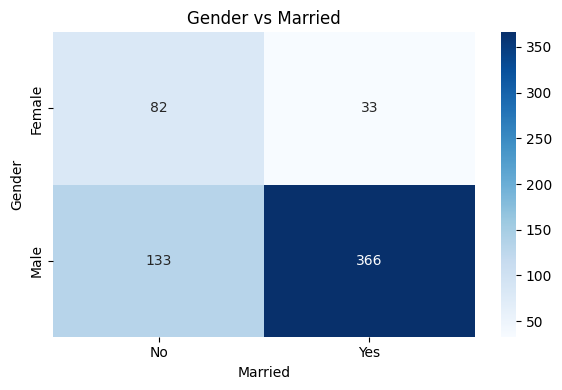


Gender vs Education
Education  Graduate  Not Graduate
Gender                           
Female           95            20
Male            385           114


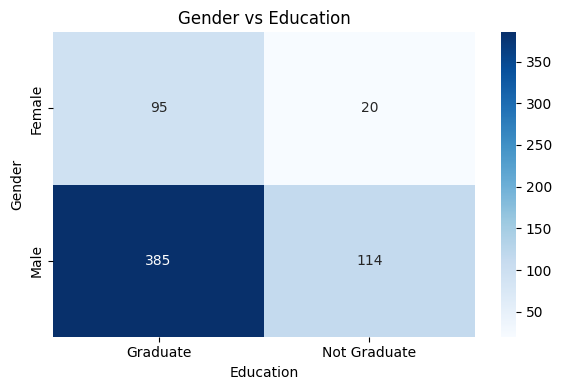


Gender vs Self_Employed
Self_Employed   No  Yes
Gender                 
Female          95   20
Male           428   71


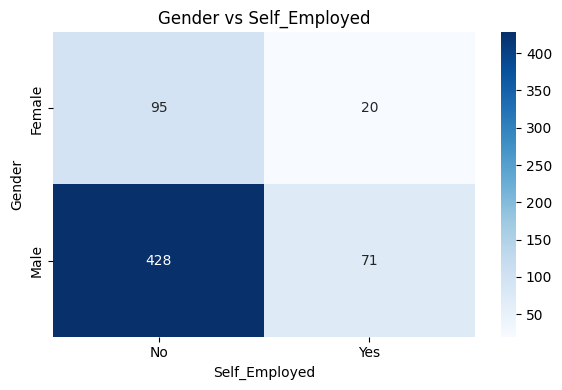


Gender vs Property_Area
Property_Area  Rural  Semiurban  Urban
Gender                                
Female            25         56     34
Male             154        177    168


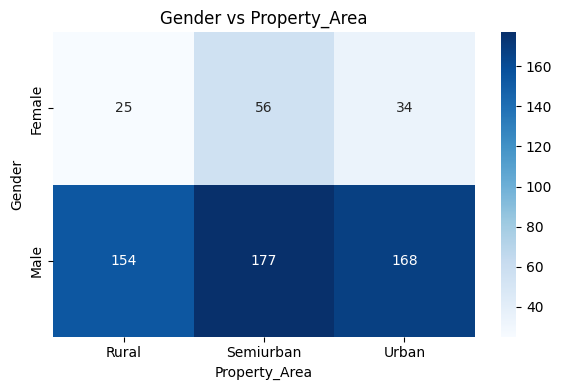


Gender vs Loan_Status
Loan_Status    N    Y
Gender               
Female        37   78
Male         155  344


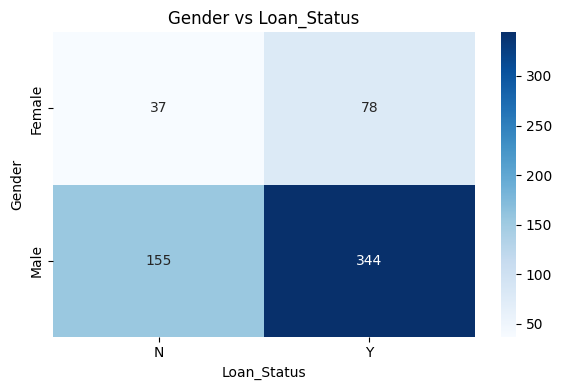


Married vs Education
Education  Graduate  Not Graduate
Married                          
No              170            45
Yes             310            89


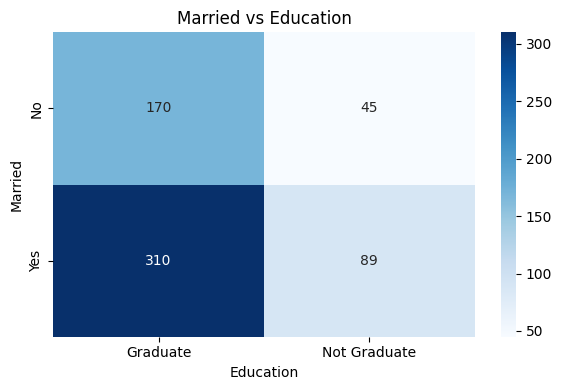


Married vs Self_Employed
Self_Employed   No  Yes
Married                
No             183   32
Yes            340   59


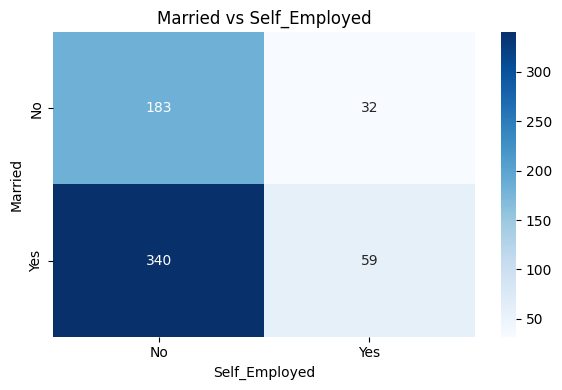


Married vs Property_Area
Property_Area  Rural  Semiurban  Urban
Married                               
No                63         82     70
Yes              116        151    132


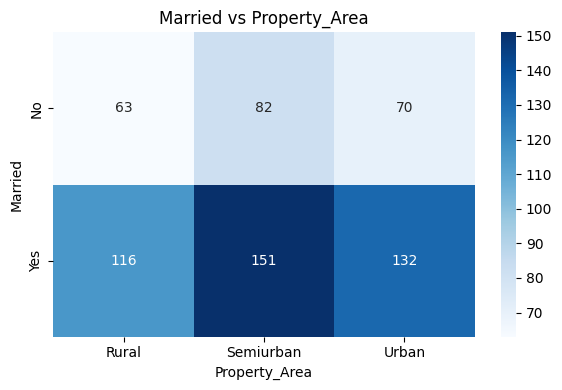


Married vs Loan_Status
Loan_Status    N    Y
Married              
No            79  136
Yes          113  286


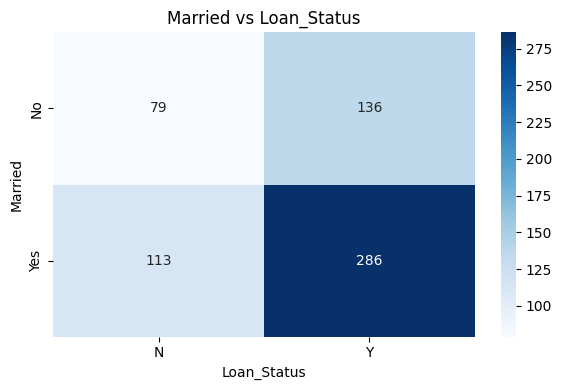


Education vs Self_Employed
Self_Employed   No  Yes
Education              
Graduate       412   68
Not Graduate   111   23


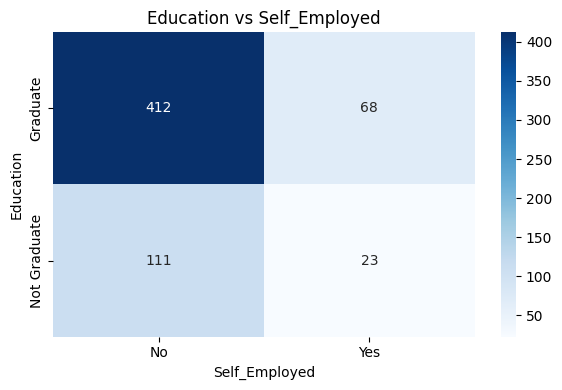


Education vs Property_Area
Property_Area  Rural  Semiurban  Urban
Education                             
Graduate         131        187    162
Not Graduate      48         46     40


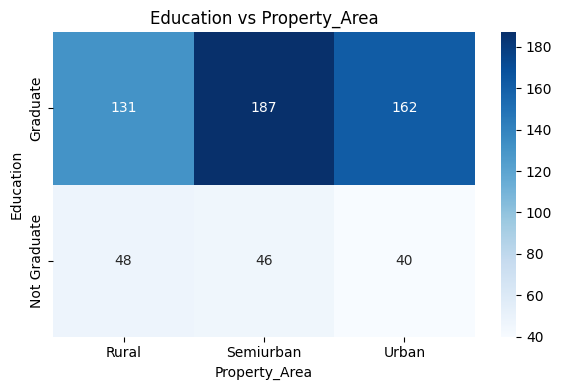


Education vs Loan_Status
Loan_Status     N    Y
Education             
Graduate      140  340
Not Graduate   52   82


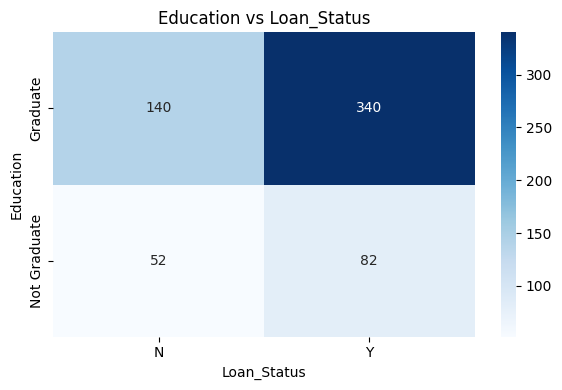


Self_Employed vs Property_Area
Property_Area  Rural  Semiurban  Urban
Self_Employed                         
No               148        197    178
Yes               31         36     24


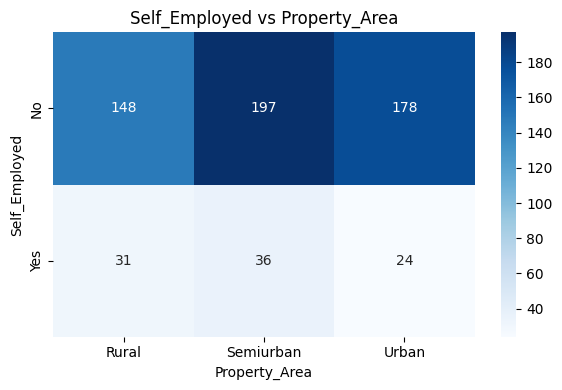


Self_Employed vs Loan_Status
Loan_Status      N    Y
Self_Employed          
No             163  360
Yes             29   62


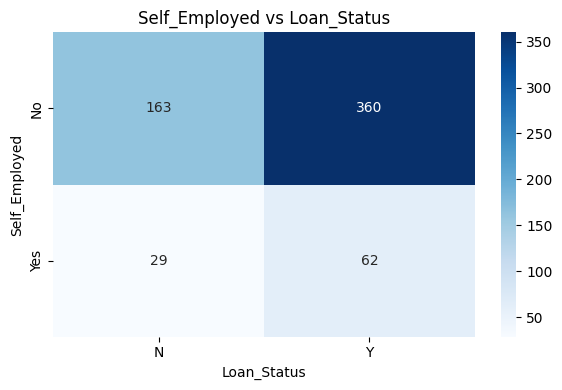


Property_Area vs Loan_Status
Loan_Status     N    Y
Property_Area         
Rural          69  110
Semiurban      54  179
Urban          69  133


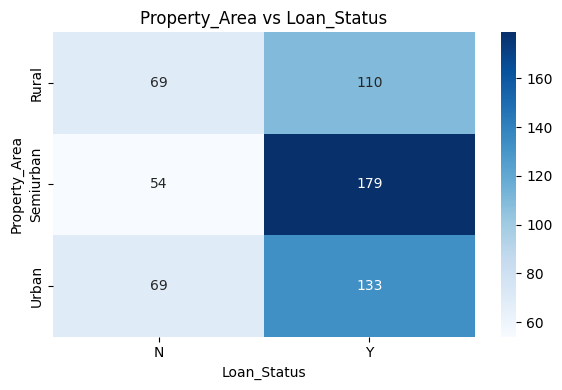

In [ ]:
cat_cols = ['Gender', 'Married', 'Education',
            'Self_Employed', 'Property_Area', 'Loan_Status']

for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        ct = pd.crosstab(df[cat_cols[i]], df[cat_cols[j]])
        print(f"\n{cat_cols[i]} vs {cat_cols[j]}")
        print(ct)

        plt.figure(figsize=(6,4))
        sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
        plt.title(f'{cat_cols[i]} vs {cat_cols[j]}')
        plt.tight_layout()
        plt.show()

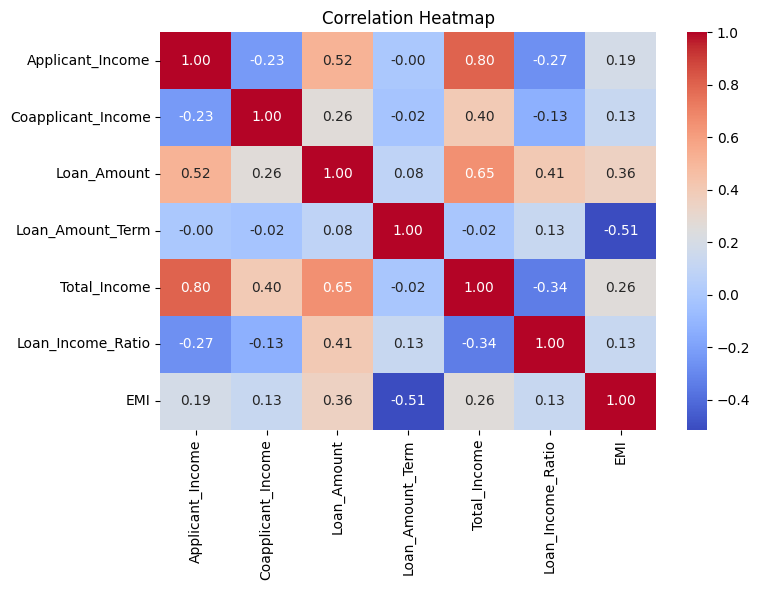

In [ ]:
df['Loan_Income_Ratio'] = df['Loan_Amount'] / df['Total_Income']
df['EMI'] = df['Loan_Amount'] / df['Loan_Amount_Term']

plt.figure(figsize=(8,6))
sns.heatmap(df[['Applicant_Income', 'Coapplicant_Income', 'Loan_Amount',
                'Loan_Amount_Term', 'Total_Income',
                'Loan_Income_Ratio', 'EMI']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

                                                                  STEP 4 FEATURE ENGINEERING

                                                                          ENCODING

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Binary columns
binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Property Area
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True, dtype=int)

print(df.head())

   Customer_ID  Gender  Married  Dependents  Education  Self_Employed  \
0          569       0        0           0          0              0   
1           15       1        1           2          0              0   
2           95       1        0           0          1              0   
3          134       1        1           0          0              1   
4          556       1        1           1          0              0   

   Applicant_Income  Coapplicant_Income  Loan_Amount  Loan_Amount_Term  \
0            2378.0                 0.0          9.0               360   
1            1299.0              1086.0         17.0               120   
2            3620.0                 0.0         25.0               120   
3            3459.0                 0.0         25.0               120   
4            5468.0              1032.0         26.0               360   

   Credit_History  Loan_Status  Total_Income  Loan_Income_Ratio       EMI  \
0               1            0        2

In [ ]:
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,Loan_Income_Ratio,EMI,Property_Area_Semiurban,Property_Area_Urban
0,569,0,0,0,0,0,2378.0,0.0,9.0,360,1,0,2378.0,0.003785,0.025000,0,1
1,15,1,1,2,0,0,1299.0,1086.0,17.0,120,1,1,2385.0,0.007128,0.141667,0,1
2,95,1,0,0,1,0,3620.0,0.0,25.0,120,1,1,3620.0,0.006906,0.208333,1,0
3,134,1,1,0,0,1,3459.0,0.0,25.0,120,1,1,3459.0,0.007228,0.208333,1,0
4,556,1,1,1,0,0,5468.0,1032.0,26.0,360,1,1,6500.0,0.004000,0.072222,1,0


                                                                  NEW FEATURES

In [ ]:
df['Total_Income'] = df['Applicant_Income'] + df['Coapplicant_Income']

df['Loan_Income_Ratio'] = df['Loan_Amount'] / df['Total_Income']

df['EMI'] = df['Loan_Amount'] / df['Loan_Amount_Term']

print(df[['Total_Income', 'Loan_Income_Ratio', 'EMI']].head())

   Total_Income  Loan_Income_Ratio       EMI
0        2378.0           0.003785  0.025000
1        2385.0           0.007128  0.141667
2        3620.0           0.006906  0.208333
3        3459.0           0.007228  0.208333
4        6500.0           0.004000  0.072222


Explanation:

1. Total_Income

The dataset had applicant income and coapplicant income as separate columns. We added both together to create Total_Income. This shows the total money coming into the household which helps the model better judge repayment ability.

2. Loan_Income_Ratio

This feature shows how big the loan is compared to the total income. If someone earns less but is asking for a big loan, this ratio will be high which means more risk. This helps the model identify risky applicants.

3. EMI

EMI is how much the applicant has to pay every month. We calculated it by dividing loan amount by loan term. If the monthly payment is too high compared to income, the chances of loan rejection increase.


                                                               FEATURE SCAILING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop(['Customer_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-2.08305795 -1.36228263 -0.7047014  ... -0.88903178 -0.7820157
   1.42814704]
 [ 0.48006346  0.73406207  0.94049502 ... -0.64195236 -0.7820157
   1.42814704]
 [ 0.48006346 -1.36228263 -0.7047014  ... -0.50076411  1.2787467
  -0.70020801]
 ...
 [ 0.48006346  0.73406207  0.94049502 ... -0.79490629 -0.7820157
  -0.70020801]
 [ 0.48006346  0.73406207  0.11789681 ... -0.76549207 -0.7820157
  -0.70020801]
 [ 0.48006346  0.73406207 -0.7047014  ... -0.6478352  -0.7820157
   1.42814704]]


                                                    STEP 5 TRAIN TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                    X_scaled, y,
                                    test_size=0.2,
                                    random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (491, 15)
X_test shape: (123, 15)
y_train shape: (491,)
y_test shape: (123,)


                                             STEP 6 MODEL SELECTION

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


                                                     STEP 7 MODEL PREDICTION

In [ ]:
y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Actual:     ", y_test.values)

Predictions: [1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0
 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1
 1 1 0 0 0 1 1 1 1 0 1 0]
Actual:      [1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0
 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0
 1 0 0 0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 0 1 1
 1 1 0 0 0 1 0 1 1 0 1 0]


                                                            STEP 8 MODEL EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8211382113821138

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.50      0.65        40
           1       0.80      0.98      0.88        83

    accuracy                           0.82       123
   macro avg       0.86      0.74      0.76       123
weighted avg       0.84      0.82      0.80       123


Confusion Matrix:
 [[20 20]
 [ 2 81]]


Model Evaluation Observations

Accuracy

The model achieved an accuracy of 82% which means it correctly predicted the loan eligibility for 101 out of 123 applicants in the test set.

Confusion Matrix

Out of 123 test samples, the model correctly identified 20 rejected loans and 81 approved loans. However it misclassified 20 rejected loans as approved and only 2 approved loans as rejected.

Class 0 - Rejected Loans

The precision is 91% which means when the model predicts rejection it is mostly correct. However the recall is only 50% which means the model is missing half of the actual rejected cases. This is a weak point of the model.

Class 1 - Approved Loans

The precision is 80% and recall is 98% which means the model is very good at identifying approved loans. It barely misses any approved applicant.

Why this imbalance?

The dataset has 422 approved loans and only 192 rejected loans. Because approved cases are more in number the model learned to predict approved more often which is why its recall for rejected loans is low.

Overall

The model performs well for a basic logistic regression project with 82% accuracy. It is better at identifying eligible applicants than rejecting ineligible ones.


                                                           STEP 10 MODEL TUNING

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Parameters jo try karenge
params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                    params,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Accuracy: 0.8024943310657596


In [ ]:
best_model = LogisticRegression(C=0.01, penalty='l2',
                                 solver='liblinear',
                                 max_iter=1000, random_state=42)

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

Accuracy: 0.8130081300813008

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.47      0.62        40
           1       0.79      0.98      0.88        83

    accuracy                           0.81       123
   macro avg       0.85      0.73      0.75       123
weighted avg       0.83      0.81      0.79       123


Confusion Matrix:
 [[19 21]
 [ 2 81]]


In [ ]:
# Final Model
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))

Final Accuracy: 0.8211382113821138


Model tuning was performed using GridSearchCV with parameters C, penalty and solver. However the default model with C=1 and l2 penalty gave better accuracy of 82% compared to the tuned model. Therefore the default Logistic Regression model was selected as the final model.

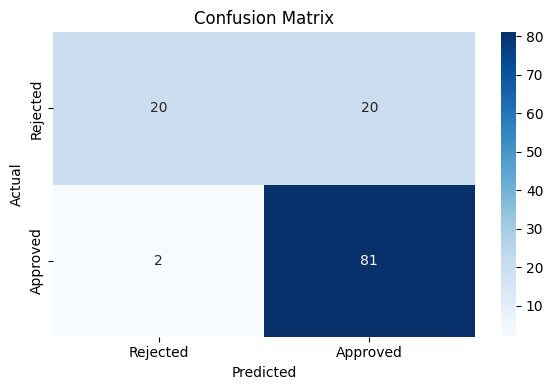

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

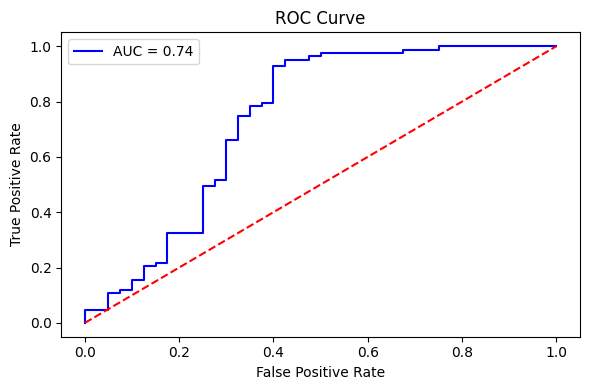

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

The ROC AUC Score of 0.74 indicates that the model has a decent ability to distinguish between eligible and non-eligible loan applicants. The model performs better at identifying approved loans compared to rejected ones which is reflected in the lower AUC score.



Logistic Regression uses the Sigmoid function internally to convert the output into a probability between 0 and 1. If the probability is greater than 0.5 the applicant is classified as eligible for a loan, otherwise they are classified as not eligible.

